# Analyze HM Dataset using Spark

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import broadcast, col

import math
import scipy.stats as stats
import numpy as np

import matplotlib.pyplot as plt

from hmcollab import directories

## 1. Start a local Spark session

In [2]:
spark = (
    SparkSession.builder
    .appName("hm_local_join")
    .master("local[*]")    # use all local cores
    .getOrCreate()
)


25/12/03 12:14:59 WARN Utils: Your hostname, fools-better-mini.local resolves to a loopback address: 127.0.0.1; using 192.168.1.176 instead (on interface en1)
25/12/03 12:14:59 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/03 12:14:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Read Data

In [3]:
base_path = directories.data("full")

In [4]:
customers = spark.read.parquet(f"{base_path}/customers.parquet")
articles  = spark.read.parquet(f"{base_path}/articles.parquet")


In [5]:
transactions = spark.read.parquet(f"{base_path}/transactions/*/*/*.parquet")


In [6]:
# Sanity checks
print("Counts:")
print("  customers   :", customers.count())
print("  articles    :", articles.count())
print("  transactions:", transactions.count())


Counts:
  customers   : 1371980
  articles    : 105542
  transactions: 31788324


In [7]:
# Inspect schema of t_dat to confirm it's timestamp/date
transactions.printSchema()


root
 |-- t_dat: timestamp_ntz (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- article_id: string (nullable = true)
 |-- price: double (nullable = true)
 |-- sales_channel_id: long (nullable = true)



## Look at data slice by month

In [8]:
transactions_jan_2019 = transactions.filter(
    (col("t_dat") >= "2019-01-01") & (col("t_dat") < "2019-02-01")
)

print("transactions in 2019-01:", transactions_jan_2019.count())


transactions in 2019-01: 1263471


In [9]:
fact = (
    transactions_jan_2019
    .join(broadcast(customers), on="customer_id", how="left")
    .join(broadcast(articles),  on="article_id",  how="left")
)

print("Joined count (2019-01):", fact.count())
fact.printSchema()


25/12/03 12:15:04 WARN MemoryStore: Not enough space to cache broadcast_20 in memory! (computed 296.0 MiB so far)
25/12/03 12:15:04 WARN BlockManager: Persisting block broadcast_20 to disk instead.
25/12/03 12:15:05 WARN MemoryStore: Not enough space to cache broadcast_20 in memory! (computed 296.0 MiB so far)
25/12/03 12:15:06 WARN TaskMemoryManager: Failed to allocate a page (67108864 bytes), try again.
25/12/03 12:15:06 WARN TaskMemoryManager: Failed to allocate a page (67108864 bytes), try again.
25/12/03 12:15:06 WARN TaskMemoryManager: Failed to allocate a page (67108864 bytes), try again.
25/12/03 12:15:06 WARN TaskMemoryManager: Failed to allocate a page (67108864 bytes), try again.
25/12/03 12:15:06 WARN TaskMemoryManager: Failed to allocate a page (67108864 bytes), try again.
25/12/03 12:15:06 WARN TaskMemoryManager: Failed to allocate a page (67108864 bytes), try again.
25/12/03 12:15:06 WARN TaskMemoryManager: Failed to allocate a page (67108864 bytes), try again.
25/12/03 

Joined count (2019-01): 1263471
root
 |-- article_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- t_dat: timestamp_ntz (nullable = true)
 |-- price: double (nullable = true)
 |-- sales_channel_id: long (nullable = true)
 |-- FN: double (nullable = true)
 |-- Active: double (nullable = true)
 |-- club_member_status: string (nullable = true)
 |-- fashion_news_frequency: string (nullable = true)
 |-- age: double (nullable = true)
 |-- postal_code: string (nullable = true)
 |-- product_code: string (nullable = true)
 |-- prod_name: string (nullable = true)
 |-- product_type_no: long (nullable = true)
 |-- product_type_name: string (nullable = true)
 |-- product_group_name: string (nullable = true)
 |-- graphical_appearance_no: long (nullable = true)
 |-- graphical_appearance_name: string (nullable = true)
 |-- colour_group_code: string (nullable = true)
 |-- colour_group_name: string (nullable = true)
 |-- perceived_colour_value_id: long (nullable = true)
 |-- 

## Analyze cardinalities and count nulls for article features

In [10]:
summary = (
    articles
    .agg(*[
        F.countDistinct(c).alias(f"{c}_distinct")
        for c in articles.columns
    ])
)

summary.show(truncate=False)

null_counts = (
    articles
    .agg(*[
        F.sum(F.col(c).isNull().cast("int")).alias(f"{c}_nulls")
        for c in articles.columns
    ])
)

null_counts.show(truncate=False)


25/12/03 12:15:40 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

+-------------------+---------------------+------------------+------------------------+--------------------------+---------------------------+--------------------------------+----------------------------------+--------------------------+--------------------------+----------------------------------+------------------------------------+-----------------------------------+-------------------------------------+----------------------+------------------------+-------------------+-------------------+-----------------------+-------------------------+-------------------+---------------------+-------------------------+---------------------------+--------------------+
|article_id_distinct|product_code_distinct|prod_name_distinct|product_type_no_distinct|product_type_name_distinct|product_group_name_distinct|graphical_appearance_no_distinct|graphical_appearance_name_distinct|colour_group_code_distinct|colour_group_name_distinct|perceived_colour_value_id_distinct|perceived_colour_value_name_distinc

In [11]:
cardinality = [
    (c, articles.select(F.countDistinct(c)).first()[0])
    for c in articles.columns
]

spark.createDataFrame(cardinality, ["column", "distinct_count"]) \
     .orderBy("distinct_count", ascending=False) \
     .show(50, truncate=False)


+----------------------------+--------------+
|column                      |distinct_count|
+----------------------------+--------------+
|article_id                  |105542        |
|product_code                |47224         |
|prod_name                   |45875         |
|detail_desc                 |43404         |
|department_no               |299           |
|department_name             |250           |
|product_type_no             |132           |
|product_type_name           |131           |
|section_no                  |57            |
|section_name                |56            |
|colour_group_code           |50            |
|colour_group_name           |50            |
|graphical_appearance_no     |30            |
|graphical_appearance_name   |30            |
|garment_group_no            |21            |
|garment_group_name          |21            |
|perceived_colour_master_id  |20            |
|perceived_colour_master_name|20            |
|product_group_name          |19  

In [12]:
nulls = [
    (c, articles.filter(F.col(c).isNull()).count())
    for c in articles.columns
]

spark.createDataFrame(nulls, ["column", "null_count"]) \
     .orderBy("null_count", ascending=False) \
     .show(50, truncate=False)


+----------------------------+----------+
|column                      |null_count|
+----------------------------+----------+
|detail_desc                 |416       |
|section_no                  |0         |
|product_type_name           |0         |
|section_name                |0         |
|index_code                  |0         |
|product_group_name          |0         |
|article_id                  |0         |
|index_name                  |0         |
|garment_group_no            |0         |
|prod_name                   |0         |
|garment_group_name          |0         |
|colour_group_code           |0         |
|product_type_no             |0         |
|perceived_colour_value_id   |0         |
|colour_group_name           |0         |
|perceived_colour_master_id  |0         |
|perceived_colour_value_name |0         |
|index_group_no              |0         |
|perceived_colour_master_name|0         |
|graphical_appearance_no     |0         |
|index_group_name            |0   

## Look for article features which are (almost) equivalent

In [13]:
articles.groupBy("product_type_no") \
        .agg(F.countDistinct("product_type_name").alias("names_per_id")) \
        .orderBy(F.desc("names_per_id")) \
        .show(20, truncate=False)


+---------------+------------+
|product_type_no|names_per_id|
+---------------+------------+
|270            |1           |
|293            |1           |
|296            |1           |
|287            |1           |
|277            |1           |
|299            |1           |
|155            |1           |
|196            |1           |
|77             |1           |
|532            |1           |
|274            |1           |
|529            |1           |
|262            |1           |
|94             |1           |
|264            |1           |
|275            |1           |
|57             |1           |
|144            |1           |
|84             |1           |
|326            |1           |
+---------------+------------+
only showing top 20 rows



In [14]:
articles.groupBy("product_type_name") \
        .agg(F.countDistinct("product_type_no").alias("ids_per_name")) \
        .orderBy(F.desc("ids_per_name")) \
        .show(20, truncate=False)


+------------------------+------------+
|product_type_name       |ids_per_name|
+------------------------+------------+
|Umbrella                |2           |
|Pyjama bottom           |1           |
|Swimwear set            |1           |
|Pyjama jumpsuit/playsuit|1           |
|T-shirt                 |1           |
|Wedge                   |1           |
|Underdress              |1           |
|Pyjama set              |1           |
|Hat/beanie              |1           |
|Jacket                  |1           |
|Cardigan                |1           |
|Sneakers                |1           |
|Polo shirt              |1           |
|Dog wear                |1           |
|Cross-body bag          |1           |
|Hair string             |1           |
|Waterbottle             |1           |
|Moccasins               |1           |
|Toy                     |1           |
|Leggings/Tights         |1           |
+------------------------+------------+
only showing top 20 rows



In [15]:
def fd_score(df, a, b):
    # max number of distinct b for each a
    return (
        df.groupBy(a)
          .agg(F.countDistinct(b).alias("n"))
          .agg(F.max("n"))
          .first()[0]
    )

pairs = [
    ("product_type_no", "product_type_name"),
    ("section_no", "section_name"),
    ("department_no", "department_name"),
]

for a, b in pairs:
    score = fd_score(articles, a, b)
    print(f"{a} → {b}: max distinct b = {score}")


product_type_no → product_type_name: max distinct b = 1
section_no → section_name: max distinct b = 1
department_no → department_name: max distinct b = 1


## Look for article features of different granularity

In [16]:
def dependency_analysis(df, fine, coarse):
    forward = (
        df.groupBy(fine)
          .agg(F.countDistinct(coarse).alias("coarse_per_fine"))
          .agg(F.max("coarse_per_fine")).first()[0]
    )
    
    backward = (
        df.groupBy(coarse)
          .agg(F.countDistinct(fine).alias("fine_per_coarse"))
          .agg(F.max("fine_per_coarse")).first()[0]
    )
    
    print(f"{fine} → {coarse}: max coarse_per_fine = {forward}")
    print(f"{coarse} → {fine}: max fine_per_coarse = {backward}")


In [17]:
pairs = [
    ("product_type_name", "product_group_name"),
    ("product_group_name", "section_name"),
    ("section_name", "department_name"),
    ("department_name", "index_name"),
    ("index_name", "index_group_name"),
]

for fine, coarse in pairs:
    print("\n---")
    dependency_analysis(articles, fine, coarse)



---
product_type_name → product_group_name: max coarse_per_fine = 2
product_group_name → product_type_name: max fine_per_coarse = 38

---
product_group_name → section_name: max coarse_per_fine = 47
section_name → product_group_name: max fine_per_coarse = 11

---
section_name → department_name: max coarse_per_fine = 12
department_name → section_name: max fine_per_coarse = 11

---
department_name → index_name: max coarse_per_fine = 3
index_name → department_name: max fine_per_coarse = 48

---
index_name → index_group_name: max coarse_per_fine = 1
index_group_name → index_name: max fine_per_coarse = 4


## Plot histograms of some article features

### Product Type Name

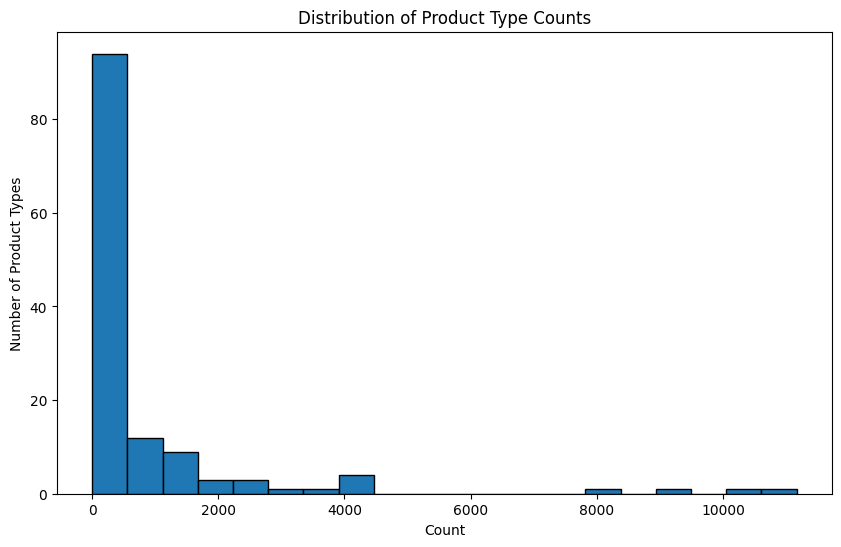

In [18]:
type_counts_df = (
    articles.groupBy("product_type_name")
            .agg(F.count("*").alias("count"))
)

type_counts = (
    type_counts_df
    .select("count")
    .rdd.flatMap(lambda x: x)
    .collect()
)

plt.figure(figsize=(10, 6))
plt.hist(type_counts, bins=20, edgecolor='black')
plt.title("Distribution of Product Type Counts")
plt.xlabel("Count")
plt.ylabel("Number of Product Types")
plt.show()




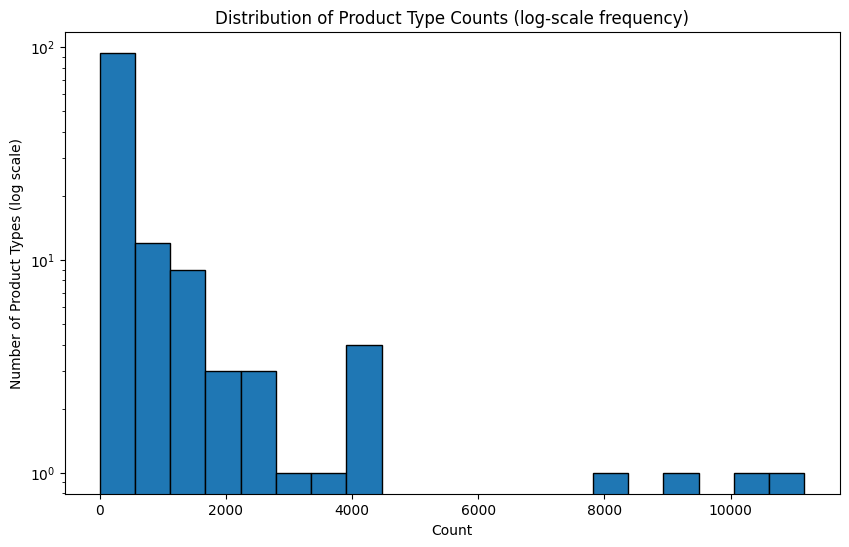

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(type_counts, bins=20, edgecolor='black')
plt.yscale('log')
plt.title("Distribution of Product Type Counts (log-scale frequency)")
plt.xlabel("Count")
plt.ylabel("Number of Product Types (log scale)")
plt.show()


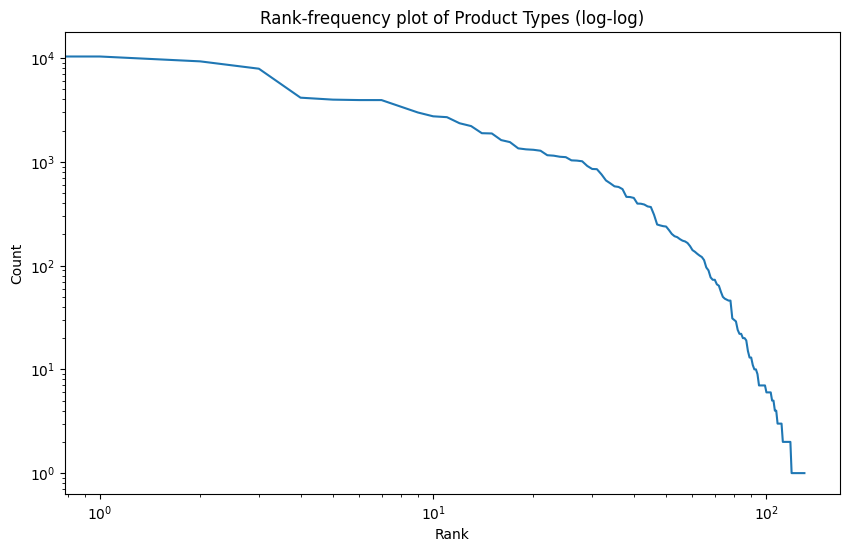

In [20]:
sorted_counts = sorted(type_counts, reverse=True)

plt.figure(figsize=(10, 6))
plt.plot(sorted_counts)
plt.yscale('log')
plt.xscale('log')
plt.title("Rank-frequency plot of Product Types (log-log)")
plt.xlabel("Rank")
plt.ylabel("Count")
plt.show()


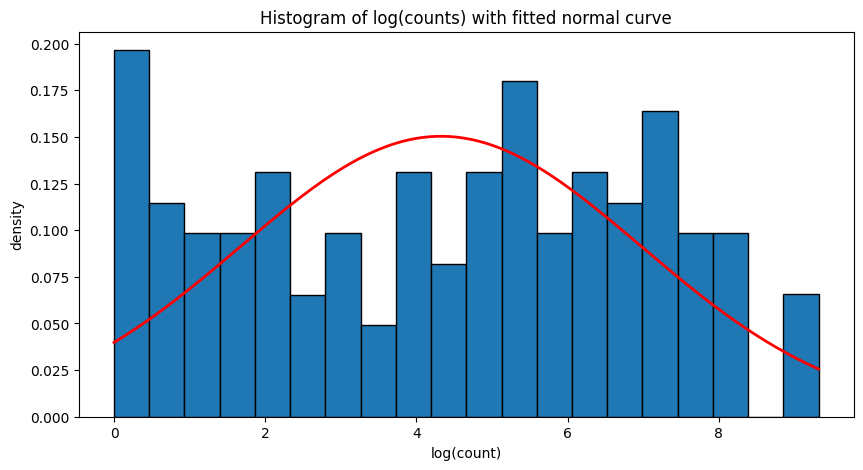

mean: 4.32584992839443 std: 2.653619232015863


In [21]:
log_counts = np.log(type_counts)

plt.figure(figsize=(10,5))
plt.hist(log_counts, bins=20, edgecolor='black', density=True)

mu, sigma = np.mean(log_counts), np.std(log_counts)
x = np.linspace(min(log_counts), max(log_counts), 200)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2)

plt.title("Histogram of log(counts) with fitted normal curve")
plt.xlabel("log(count)")
plt.ylabel("density")
plt.show()

print("mean:", mu, "std:", sigma)


## Plot article features

In [22]:
def plot_category_count_distributions(df, col, bins=20):
    """
    For a given categorical column `col` in Spark DataFrame `df`,
    compute category counts and plot:
      1) Histogram of counts
      2) Histogram of counts with log-scale y-axis
      3) Rank-frequency plot (log-log)
    """

    # 1. Compute counts per category in Spark
    counts_df = (
        df.groupBy(col)
          .agg(F.count("*").alias("count"))
    )

    # 2. Collect counts into a Python list
    counts = (
        counts_df
        .select("count")
        .rdd.flatMap(lambda x: x)
        .collect()
    )

    if not counts:
        print(f"No counts to plot for column {col}")
        return

    # ------------------------------------------------------------------
    # Plot 1: Histogram of counts (linear scale)
    # ------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.hist(counts, bins=bins, edgecolor='black')
    plt.title(f"Distribution of counts for {col}")
    plt.xlabel("Count per category")
    plt.ylabel(f"Number of distinct {col} values")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------
    # Plot 2: Histogram of counts with log-scale on y-axis
    # ------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.hist(counts, bins=bins, edgecolor='black')
    plt.yscale('log')
    plt.title(f"Distribution of counts for {col} (log-scale frequency)")
    plt.xlabel("Count per category")
    plt.ylabel(f"Number of distinct {col} values (log scale)")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------
    # Plot 3: Rank-frequency (log-log) plot
    # ------------------------------------------------------------------
    sorted_counts = sorted(counts, reverse=True)

    plt.figure(figsize=(10, 6))
    plt.plot(sorted_counts)
    plt.yscale('log')
    plt.xscale('log')
    plt.title(f"Rank-frequency plot for {col} (log-log)")
    plt.xlabel("Rank")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


### Section Name

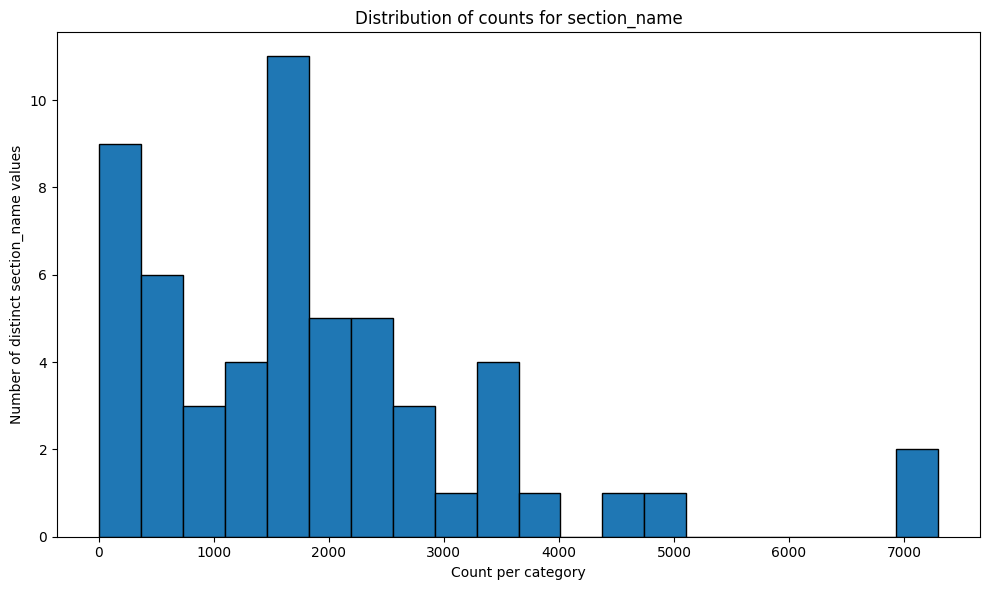

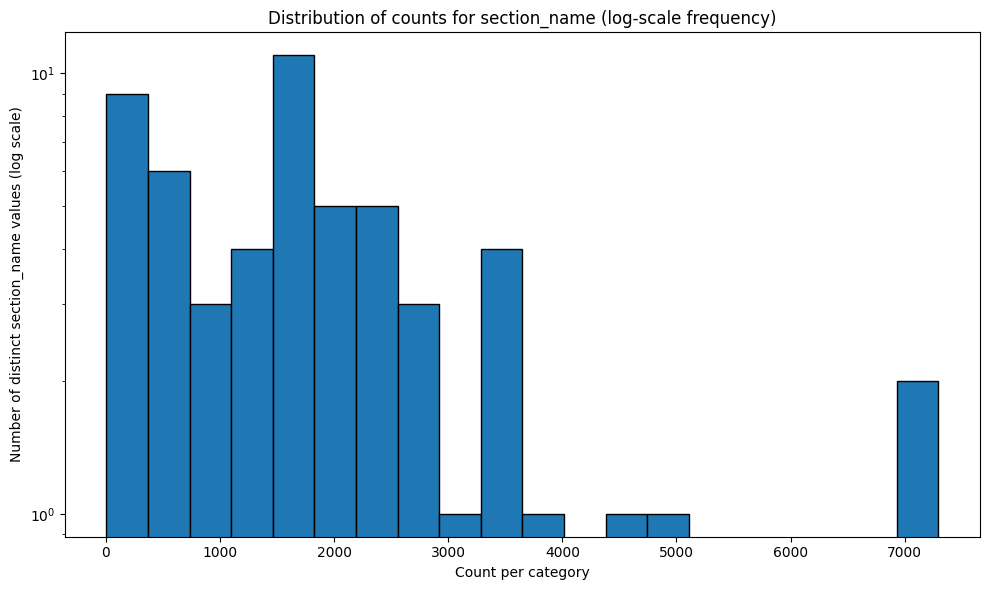

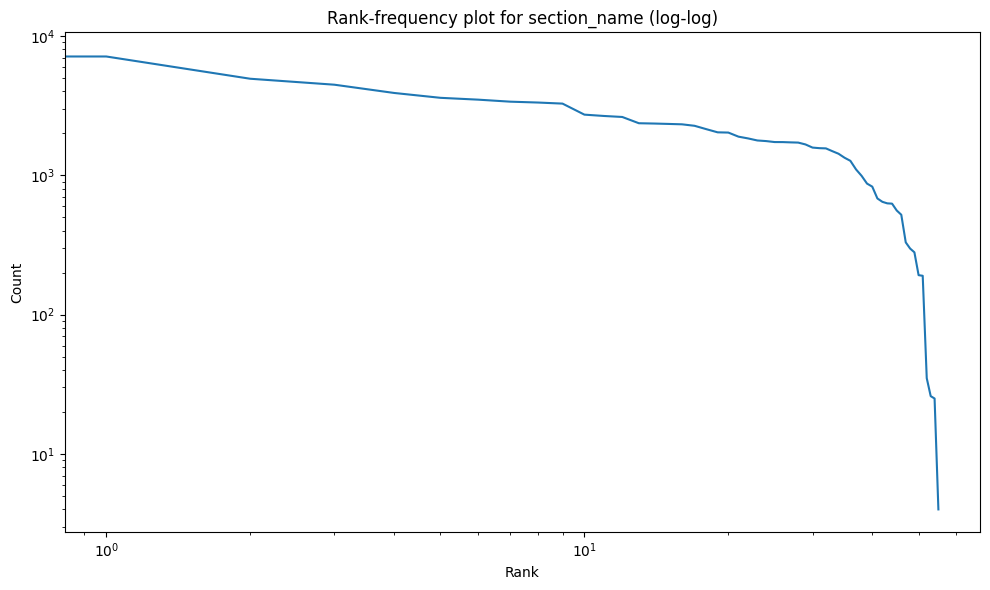

In [23]:
plot_category_count_distributions(articles, "section_name")

### Index Group Name

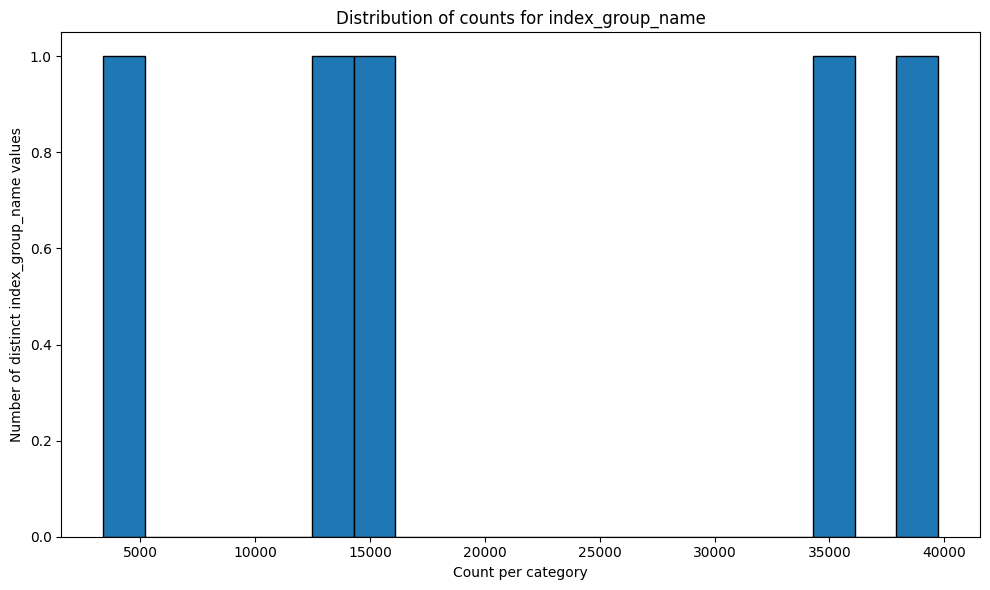

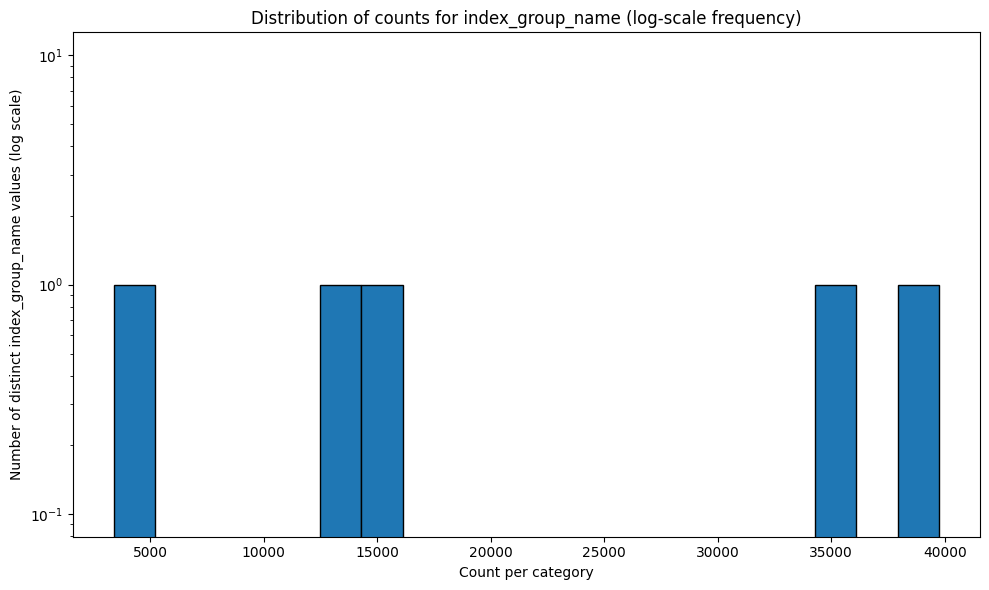

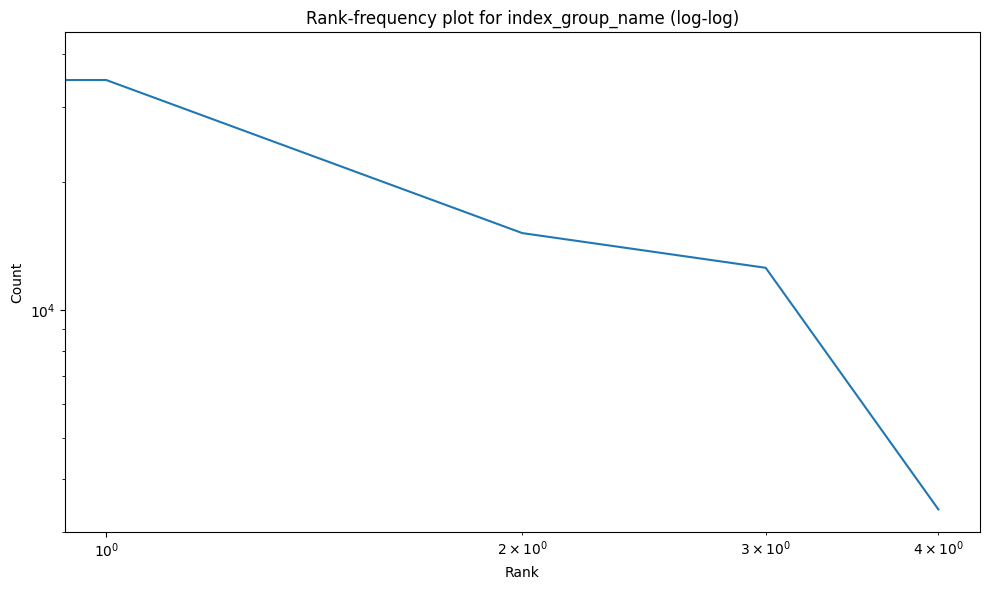

In [24]:
plot_category_count_distributions(articles, "index_group_name")

## Customer features

### Age

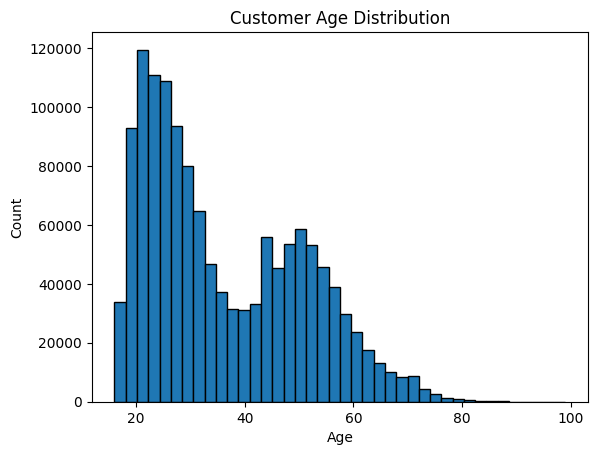

In [25]:
ages = (
    customers.select("age")
             .filter("age IS NOT NULL")
             .rdd.flatMap(lambda x: x)
             .collect()
)

plt.hist(ages, bins=40, edgecolor='black')
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


### Club member status

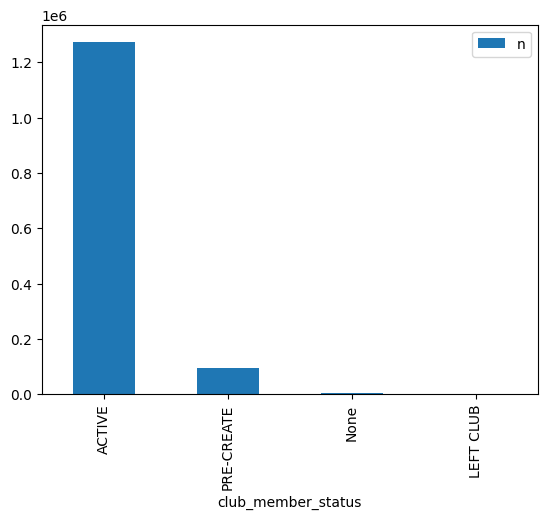

In [26]:
status_counts = (
    customers.groupBy("club_member_status")
             .agg(F.count("*").alias("n"))
             .orderBy("n", ascending=False)
             .toPandas()
)

status_counts.plot.bar(x="club_member_status", y="n")
plt.show()


### Feature entropy

In [27]:
def entropy(df, col):
    counts = df.groupBy(col).agg(F.count("*").alias("n"))
    total = counts.agg(F.sum("n")).first()[0]

    probs = counts.withColumn("p", F.col("n") / total)
    ent = probs.select(F.sum(-F.col("p") * F.log2("p")).alias("entropy")).first()[0]
    return ent

print("club_member_status entropy:", entropy(customers, "club_member_status"))
print("fashion_news_frequency entropy:", entropy(customers, "fashion_news_frequency"))


club_member_status entropy: 0.4023432292406549
fashion_news_frequency entropy: 1.0237249963501531


## Basic customer transaction insights

This demonstration is designed to run locally on a single month of data.

In [28]:
def build_rfm(transactions_df, date_col="t_dat", price_col="price"):
    """
    Given a Spark DataFrame of transactions with at least:
      - customer_id
      - date_col (default 't_dat')
      - price_col (default 'price')
    compute per-customer RFM:
      - frequency: number of transactions
      - last_purchase: latest transaction date
      - monetary: total spend
      - recency_days: days from last_purchase to dataset max date
    and return an RFM DataFrame.
    """

    # global max date for this dataset (can be one month or full history)
    max_date = transactions_df.agg(F.max(date_col).alias("max_date")).first()["max_date"]

    rfm = (
        transactions_df
        .groupBy("customer_id")
        .agg(
            F.count("*").alias("frequency"),
            F.max(date_col).alias("last_purchase"),
            F.sum(price_col).alias("monetary"),
        )
        .withColumn(
            "recency_days",
            F.datediff(F.lit(max_date), F.col("last_purchase"))
        )
        .select("customer_id", "frequency", "recency_days", "monetary")
    )

    return rfm


In [30]:
# One-month transactions DF (local demo)
transactions_2019_01 = spark.read.parquet(
    f"{base_path}/transactions/2019/01/2019-01.parquet"
)

rfm_2019_01 = build_rfm(transactions_2019_01)

# Quick sanity check – this should now be cheap
rfm_2019_01.select(
    F.min("frequency").alias("min_freq"),
    F.max("frequency").alias("max_freq"),
    F.min("recency_days").alias("min_recency"),
    F.max("recency_days").alias("max_recency"),
    F.min("monetary").alias("min_monetary"),
    F.max("monetary").alias("max_monetary"),
).show()


+--------+--------+-----------+-----------+-----------------+------------------+
|min_freq|max_freq|min_recency|max_recency|     min_monetary|      max_monetary|
+--------+--------+-----------+-----------+-----------------+------------------+
|       1|     258|          0|         30|8.474576271186E-4|11.082898305084761|
+--------+--------+-----------+-----------+-----------------+------------------+



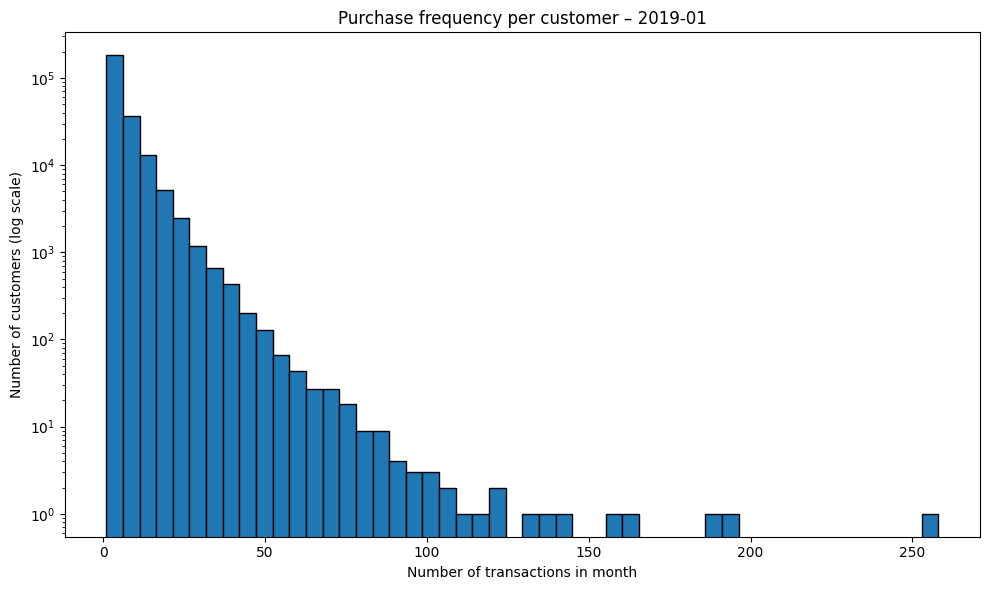

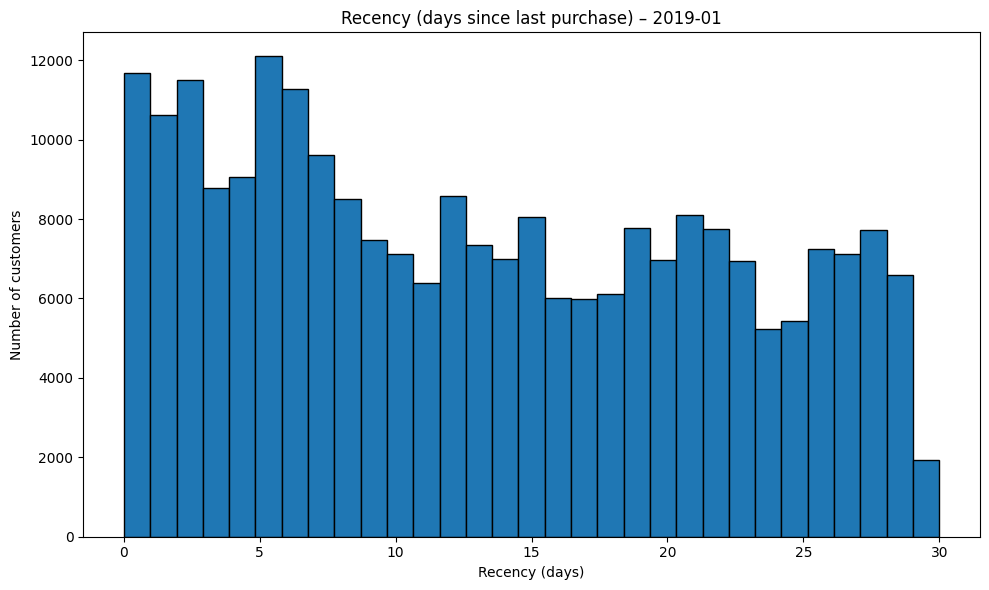

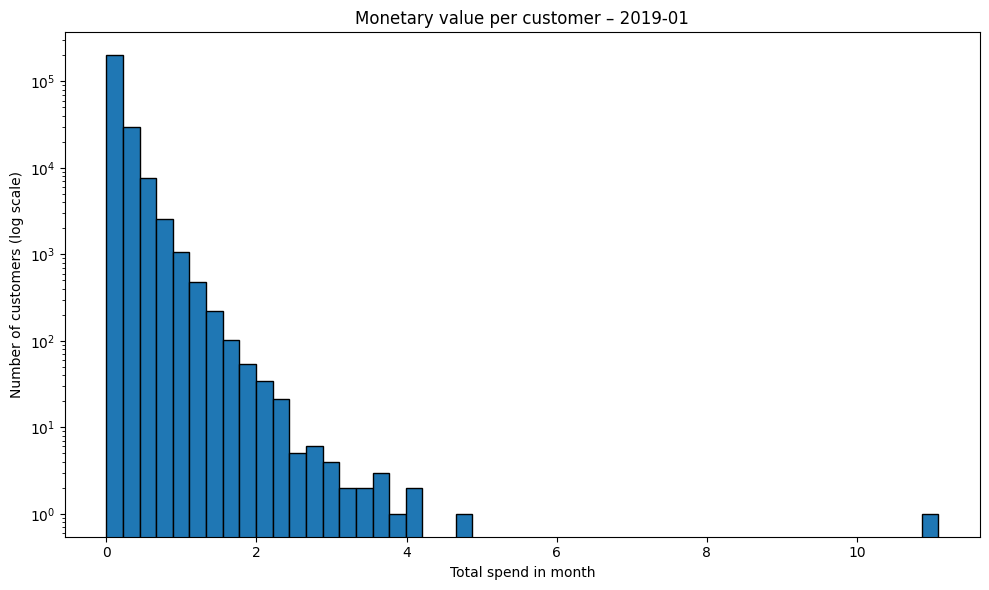

In [31]:
freq = rfm_2019_01.select("frequency").rdd.flatMap(lambda x: x).collect()
rec  = rfm_2019_01.select("recency_days").rdd.flatMap(lambda x: x).collect()
mon  = rfm_2019_01.select("monetary").rdd.flatMap(lambda x: x).collect()

# Frequency
plt.figure(figsize=(10, 6))
plt.hist(freq, bins=50, edgecolor="black")
plt.yscale("log")
plt.title("Purchase frequency per customer – 2019-01")
plt.xlabel("Number of transactions in month")
plt.ylabel("Number of customers (log scale)")
plt.tight_layout()
plt.show()

# Recency (within that month)
plt.figure(figsize=(10, 6))
plt.hist(rec, bins=31, edgecolor="black")
plt.title("Recency (days since last purchase) – 2019-01")
plt.xlabel("Recency (days)")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

# Monetary (log-scale y)
mon_pos = [x for x in mon if x > 0]

plt.figure(figsize=(10, 6))
plt.hist(mon_pos, bins=50, edgecolor="black")
plt.yscale("log")
plt.title("Monetary value per customer – 2019-01")
plt.xlabel("Total spend in month")
plt.ylabel("Number of customers (log scale)")
plt.tight_layout()
plt.show()
